<a href="https://colab.research.google.com/github/Misthi28/Atlas/blob/main/Stock_Price_Prediction_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas_datareader as data

plt.style.use('fivethirtyeight')
%matplotlib inline

In [ ]:
import yfinance as yf
import datetime as dt

stock = "POWERGRID.NS"
start = dt.datetime(2000, 1, 1)
end = dt.datetime(2024, 11, 1)

df = yf.download(stock, start, end)

/tmp/ipython-input-2487901451.py:8: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed


In [ ]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS
Date,,,,,
2007-10-05,31.243086,34.007137,25.823683,27.888958,855215656
2007-10-08,29.643660,32.299011,29.457318,32.299011,126671715
2007-10-09,31.662342,31.941852,28.059761,29.659181,116725709
2007-10-10,31.957403,32.609596,31.677893,32.485368,67931378
2007-10-11,35.528923,37.268102,31.677888,37.268102,106320954


In [ ]:
df.shape

(4208, 5)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4208 entries, 2007-10-05 to 2024-10-31
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   (Close, POWERGRID.NS)   4208 non-null   float64
 1   (High, POWERGRID.NS)    4208 non-null   float64
 2   (Low, POWERGRID.NS)     4208 non-null   float64
 3   (Open, POWERGRID.NS)    4208 non-null   float64
 4   (Volume, POWERGRID.NS)  4208 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 197.2 KB


In [ ]:
df.isnull().sum()

,,0
Price,Ticker,
Close,POWERGRID.NS,0
High,POWERGRID.NS,0
Low,POWERGRID.NS,0
Open,POWERGRID.NS,0
Volume,POWERGRID.NS,0


In [ ]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS
count,4208.000000,4208.000000,4208.000000,4208.000000,4.208000e+03
mean,76.940540,77.940330,75.952691,76.976097,1.188963e+07
std,62.451612,63.182031,61.673576,62.433572,2.061999e+07
min,18.241360,19.499384,16.354323,19.405032,0.000000e+00
25%,35.067375,35.620608,34.549476,35.103287,4.799653e+06
50%,53.283852,53.899082,52.570758,53.386146,8.344398e+06
75%,79.787119,80.739502,78.841019,79.808829,1.362032e+07
max,348.714539,349.477891,340.842340,347.378627,8.552157e+08


In [ ]:
df = df.reset_index()

In [ ]:
df.columns

MultiIndex([(  'Date',             ''),
            ( 'Close', 'POWERGRID.NS'),
            (  'High', 'POWERGRID.NS'),
            (   'Low', 'POWERGRID.NS'),
            (  'Open', 'POWERGRID.NS'),
            ('Volume', 'POWERGRID.NS')],
           names=['Price', 'Ticker'])

In [ ]:
df.to_csv("powergrid.csv")

In [ ]:
data01 = pd.read_csv("powergrid.csv")

In [ ]:
data01.head()

,Price,Date,Close,High,Low,Open,Volume
0,Ticker,NaN,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS
1,0,2007-10-05,31.243085861206055,34.007136830991804,25.82368334804961,27.88895770674675,855215656
2,1,2007-10-08,29.643659591674805,32.29901067901004,29.457318351585858,32.29901067901004,126671715
3,2,2007-10-09,31.662342071533203,31.941851779936375,28.059760795619255,29.659181438690247,116725709
4,3,2007-10-10,31.9574031829834,32.60959577240613,31.677893276756887,32.48536750928385,67931378


In [ ]:
# Candlesticks  , generates an interactive stock-market candlestick chart using your dataset (Open, High, Low, Close values).
import plotly.graph_objects as go

fig = go.Figure(data=[go.Candlestick(x = data01['Date'], open = data01['Open'],
                                    high = data01['High'],
                                    low = data01['Low'],
                                    close = data01['Close'])])
fig.update_layout(xaxis_rangeslider_visible=False)
fig.show()

In [ ]:
df.columns = df.columns.droplevel(1)


In [ ]:
df.head()


Price,Date,Close,High,Low,Open,Volume
0,2007-10-05,31.243086,34.007137,25.823683,27.888958,855215656
1,2007-10-08,29.643660,32.299011,29.457318,32.299011,126671715
2,2007-10-09,31.662342,31.941852,28.059761,29.659181,116725709
3,2007-10-10,31.957403,32.609596,31.677893,32.485368,67931378
4,2007-10-11,35.528923,37.268102,31.677888,37.268102,106320954


In [ ]:
print(df.columns)


Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')


In [ ]:
# df = df.drop(['Date', 'Adj Close'], axis = 1)
df = df.drop(['Date'], axis=1)


In [ ]:
df.head()

Price,Close,High,Low,Open,Volume
0,31.243086,34.007137,25.823683,27.888958,855215656
1,29.643660,32.299011,29.457318,32.299011,126671715
2,31.662342,31.941852,28.059761,29.659181,116725709
3,31.957403,32.609596,31.677893,32.485368,67931378
4,35.528923,37.268102,31.677888,37.268102,106320954


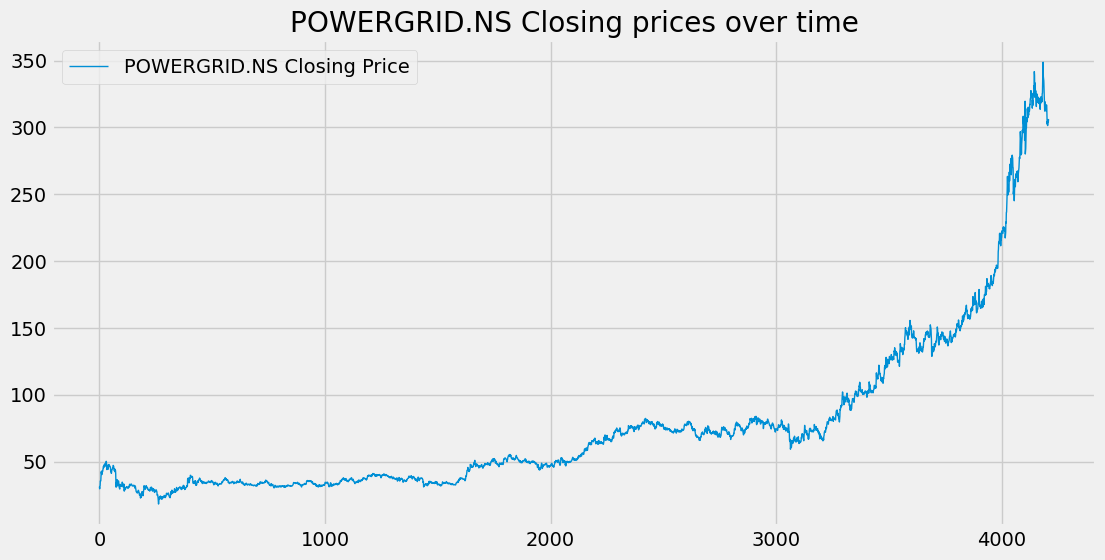

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(df['Close'], label = f'{stock} Closing Price', linewidth = 1)
plt.title(f'{stock} Closing prices over time')
plt.legend()
plt.show()

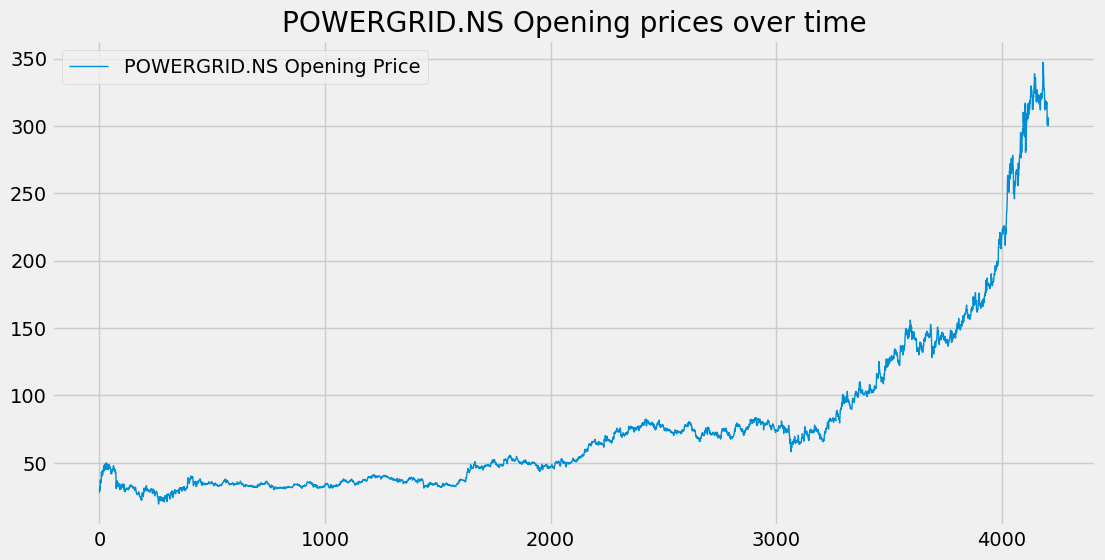

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(df['Open'], label = f'{stock} Opening Price', linewidth = 1)
plt.title(f'{stock} Opening prices over time')
plt.legend()
plt.show()

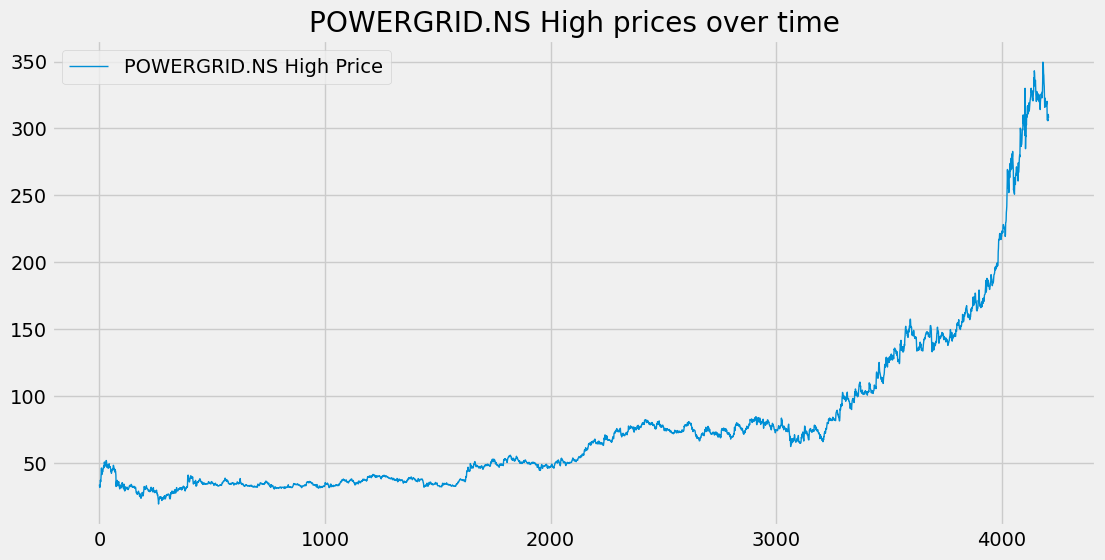

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(df['High'], label = f'{stock} High Price', linewidth = 1)
plt.title(f'{stock} High prices over time')
plt.legend()
plt.show()

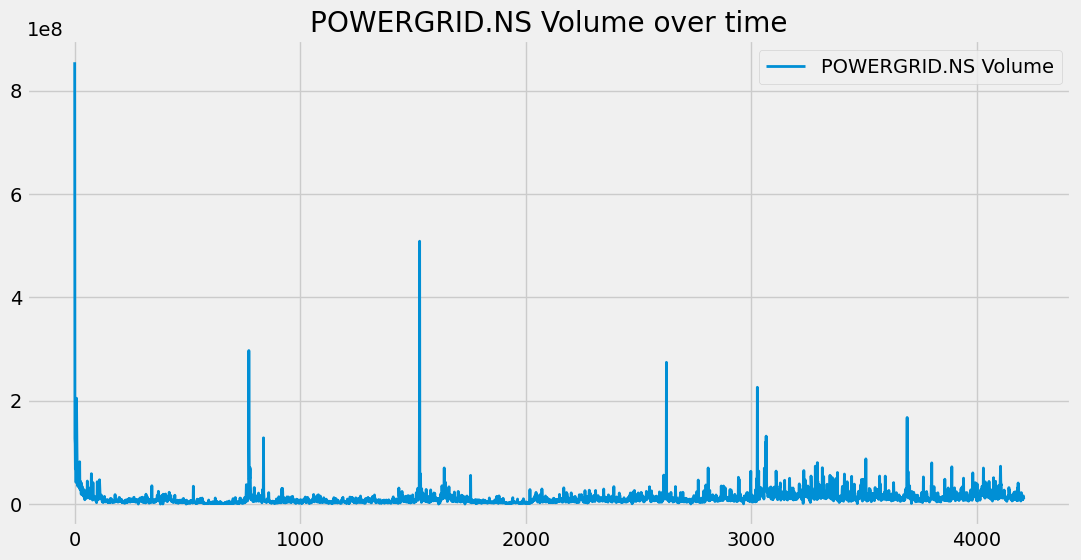

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(df['Volume'], label = f'{stock} Volume', linewidth = 2)
plt.title(f'{stock} Volume over time')
plt.legend()
plt.show()

In [ ]:
# Moving Average
# [10, 20, 30, 40, 50, 60, 70, 80, 90]
# moving average for last 5 days -> null null null null 30.0 40.0 50.0

temp_data = [10, 20, 30, 40, 50, 60, 70, 80, 90]
print(sum(temp_data[2:7])/5)

50.0


In [ ]:
import pandas as pd
df01 = pd.DataFrame(temp_data)

In [ ]:
df01.rolling(5).mean()

,0
0,NaN
1,NaN
2,NaN
3,NaN
4,30.0
5,40.0
6,50.0
7,60.0
8,70.0


In [ ]:
ma100 = df.Close.rolling(100).mean()

In [ ]:
ma100

,Close
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
4203,318.240846
4204,318.477396
4205,318.708447
4206,318.903844


In [ ]:
ma200 = df.Close.rolling(200).mean()

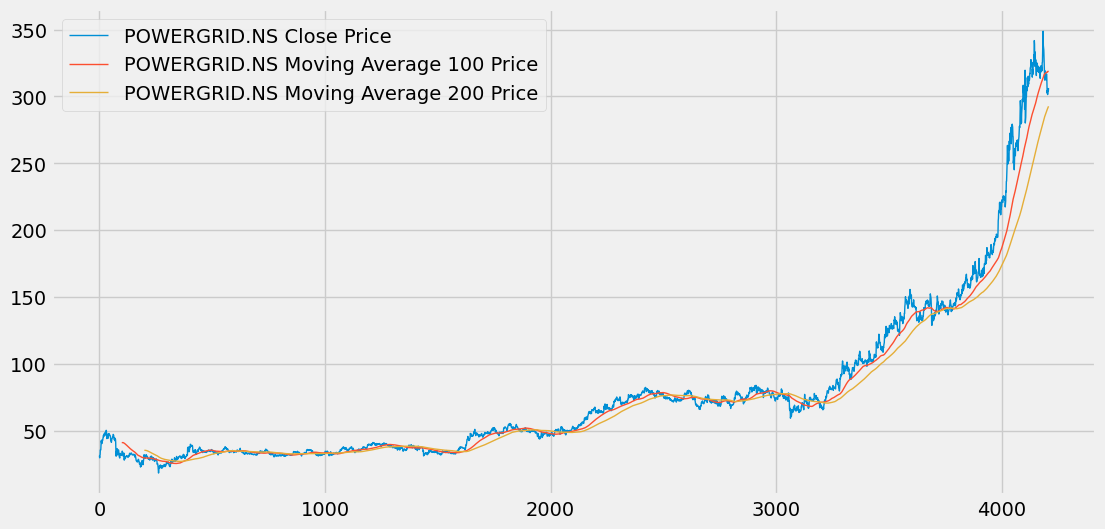

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(df.Close, label = f'{stock} Close Price', linewidth = 1)
plt.plot(ma100, label = f'{stock} Moving Average 100 Price', linewidth = 1)
plt.plot(ma200, label = f'{stock} Moving Average 200 Price', linewidth = 1)
plt.legend()
plt.show()

In [ ]:
ema100 = df.Close.ewm(span=100, adjust = False).mean()

In [ ]:
ema200 = df['Close'].ewm(span=200, adjust = False).mean()

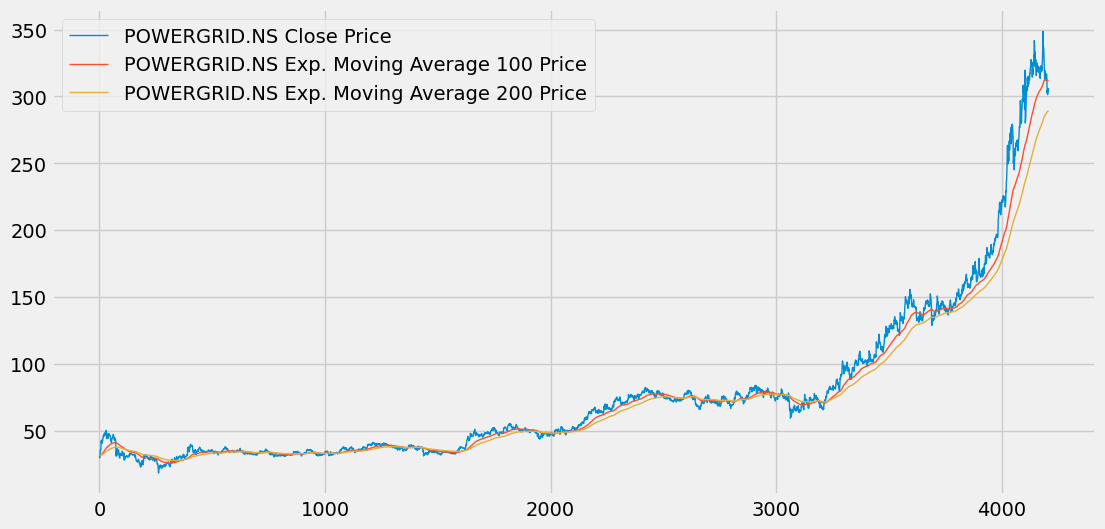

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(df.Close, label = f'{stock} Close Price', linewidth = 1)
plt.plot(ema100, label = f'{stock} Exp. Moving Average 100 Price', linewidth = 1)
plt.plot(ema200, label = f'{stock} Exp. Moving Average 200 Price', linewidth = 1)
plt.legend()
plt.show()

In [ ]:
# Training & Testing

data_training = pd.DataFrame(df['Close'][0:int(len(df)*0.70)])
data_testing = pd.DataFrame(df['Close'][int(len(df)*0.70): int(len(df))])

In [ ]:
data_training.shape

(2945, 1)

In [ ]:
data_testing.shape

(1263, 1)

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range = (0, 1))

In [ ]:
data_training_array = scaler.fit_transform(data_training)

In [ ]:
data_training_array

array([[0.19808613],
       [0.17371828],
       [0.20447366],
       ...,
       [0.90774459],
       [0.86000398],
       [0.87299657]])

In [ ]:
data_training_array.shape[0]

2945

In [ ]:
x_train = []
y_train = []

for i in range(100, data_training_array.shape[0]):
    x_train.append(data_training_array[i-100:i])
    y_train.append(data_training_array[i, 0])

x_train, y_train  = np.array(x_train), np.array(y_train)

In [ ]:
x_train.shape

(2845, 100, 1)

In [ ]:
# Model Building
from keras.layers import Dense, Dropout, LSTM
from keras.models import Sequential

LSTM Input -> 3D Array (batch_size, time_steps, seq_len)
LSTM 2D OR 3D
2D -> (batch_sizem units)
3D -> (batch_size, time_steps, units)

In [ ]:
model = Sequential() #a 4-layer stacked LSTM model with increasing units.

model.add(LSTM(units = 50, activation = 'relu', return_sequences = True, input_shape = (x_train.shape[1],1)))
model.add(Dropout(0.2))           #Applies dropout to prevent overfitting

model.add(LSTM(units = 60, activation = 'relu', return_sequences = True))
model.add(Dropout(0.3))

model.add(LSTM(units = 80, activation = 'relu', return_sequences = True))
model.add(Dropout(0.4))

model.add(LSTM(units = 120, activation = 'relu'))
model.add(Dropout(0.5))

model.add(Dense(units = 1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 50)        │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 50)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100, 60)        │        26,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100, 60)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 100, 80)        │        45,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100, 80)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 120)            │        96,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           121 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 178,761 (698.29 KB)

 Trainable params: 178,761 (698.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer = 'adam', loss = 'mean_squared_error')   #Model compilation and training
model.fit(x_train, y_train, epochs = 50)

Epoch 1/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 36s 328ms/step - loss: 0.0775
Epoch 2/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 23s 262ms/step - loss: 0.0100
Epoch 3/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 41s 258ms/step - loss: 0.0068
Epoch 4/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 42s 274ms/step - loss: 0.0074
Epoch 5/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 22s 243ms/step - loss: 0.0055
Epoch 6/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 43s 261ms/step - loss: 0.0056
Epoch 7/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 23s 259ms/step - loss: 0.0050
Epoch 8/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 41s 256ms/step - loss: 0.0051
Epoch 9/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 23s 259ms/step - loss: 0.0049
Epoch 10/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 23s 255ms/step - loss: 0.0045
Epoch 11/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 22s 246ms/step - loss: 0.0046
Epoch 12/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 42s 258ms/step - loss: 0.0039
Epoch 13/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 22s 251ms/step - loss: 0.0045
Epoch 14/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 22s 244ms/step - loss: 0.0039
Epoch 15/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 23s 

In [ ]:
past_100_days = data_training.tail(100)

NameError: name 'data_training' is not defined

In [ ]:
final_df = pd.concat([past_100_days, data_testing], ignore_index=True)


In [ ]:
final_df.head()

,Close
0,73.060188
1,74.549606
2,74.804375
3,74.647591
4,75.078751


In [ ]:
input_data = scaler.fit_transform(final_df)

In [ ]:
x_test = []
y_test = []

for i in range(100, input_data.shape[0]):
    x_test.append(input_data[i-100:i])
    y_test.append(input_data[i, 0])

x_test, y_test  = np.array(x_test), np.array(y_test)

In [ ]:
x_test.shape

(1263, 100, 1)

In [ ]:
y_predicted = model.predict(x_test)

40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step


In [ ]:
y_predicted.shape

(1263, 1)

In [ ]:
scaler.scale_

array([0.00345503])

In [ ]:
scaler_factor = 1 / 0.0035166
y_predicted = y_predicted * scaler_factor
y_test = y_test * scaler_factor

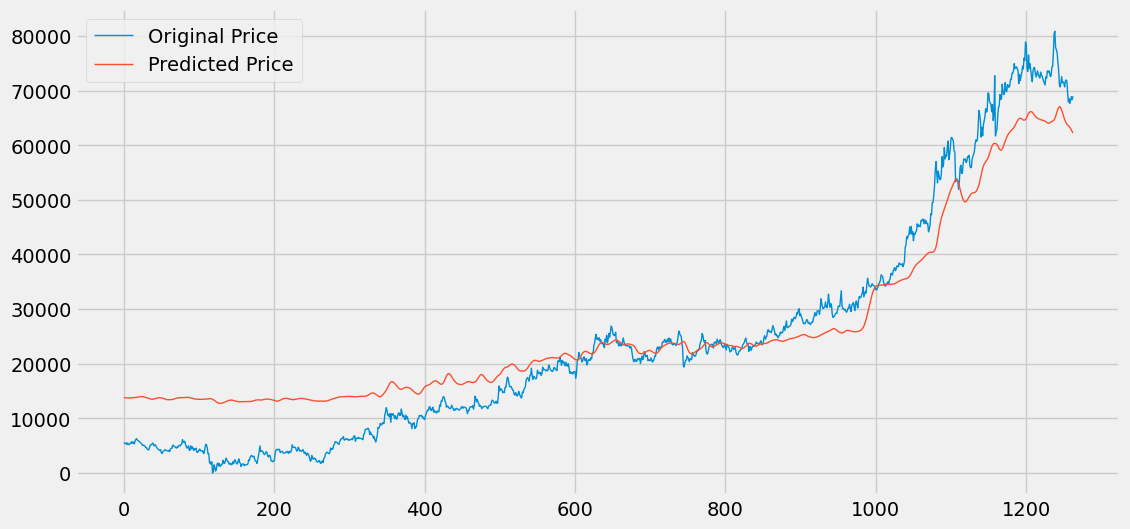

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(y_test, label = 'Original Price', linewidth = 1)
plt.plot(y_predicted, label = 'Predicted Price', linewidth = 1)
plt.legend()
plt.show()

In [ ]:
model.save('stock_dl_model.keras')


In [ ]:
from google.colab import files
files.download('stock_dl_model.keras')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>